In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import html

from sklearn.decomposition import PCA

# roodmus
from roodmus.analysis.utils import load_data
from roodmus.analysis.plot_frames import (
    plotFrameDistribution,
    plot_frame_distribution
)

### Make frames plot for first 2D Class (total 2 classes)

In [3]:
# data loading for DE-Shaw covid spike partially open set
project_dir = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included"
config_dir = os.path.join(project_dir, "Micrographs")
figures_dir = os.path.join(project_dir, "figures-3DClassDists")

meta_file = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star"
jobtypes = {
    "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star": "2 Classes - Class 1",
}


particle_diameter = 100 # approximate particle diameter in Angstroms
ugraph_shape = (4000, 4000) # shape of the micrograph in pixels. Only needs to be given if the metadata file is a .star file
verbose = True
ignore_missing_files = True
enable_tqdm = True

print(meta_file)
for file in meta_file:
    if file.endswith(".star"):
        print("is star")
    else:
        print("not star")
print(type(meta_file))

analysis = load_data(meta_file, config_dir, particle_diameter, ugraph_shape=ugraph_shape, verbose=verbose, enable_tqdm=enable_tqdm, ignore_missing_files=ignore_missing_files) # creates the class
df_picked = pd.DataFrame(analysis.results_picking)
df_truth = pd.DataFrame(analysis.results_truth)
df_precision, df_picked, pdb_labels = analysis.compute_precision(df_picked, df_truth, verbose=verbose)

print("df picked")
df_picked.tail()

print("df truth")
df_truth.tail()

print("pdb labels")
print(pdb_labels)

/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
n

loading truth data: 100%|██████████| 55/55 [00:10<00:00,  5.06it/s, micrograph=000054.mrc]


Loaded ground-truth particle positions from config files
Dictionaries now contain 6836 particles and 16500 true particles
Added 16500 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Micrographs
For each micrograph, for each metadata file, compute the precision, recall and multiplicity
Speed of computation depends on the number of particles in the micrograph. progressbar is not accurate
Total number of groups to loop over: 55
Number of micgrographs: 55
Number of metadata files: 1
Starting loop over groups


computing precision: 100%|██████████| 55/55 [00:01<00:00, 30.41it/s, precision=0.984, recall=0.422, multiplicity=0.433]


time taken to compute precision: 1.821439504623413
df picked
df truth
pdb labels
['/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb', '/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttq.pdb']


In [4]:
df_picked.tail()

,metadata_filename,ugraph_filename,position_x,position_y,euler_phi,euler_theta,euler_psi,ugraph_shape,defocusU,defocusV,class2D,TP,closest_dist,closest_particle,closest_pdb,closest_pdb_index
6831,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,000054.mrc,1128.0,498.0,1.730789,1.321803,1.615113,"(4000, 4000)",19099.601562,19082.550781,1,True,21.049109,145,/mnt/dinaMISMO/synthetic_datasets/Conformation...,1.0
6832,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,000054.mrc,1158.0,2682.0,1.090922,0.506491,-0.757747,"(4000, 4000)",19099.601562,19082.550781,1,True,37.237405,8,/mnt/dinaMISMO/synthetic_datasets/Conformation...,1.0
6833,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,000054.mrc,3672.0,3066.0,1.530938,1.486952,1.484477,"(4000, 4000)",19099.601562,19082.550781,1,True,17.827066,149,/mnt/dinaMISMO/synthetic_datasets/Conformation...,1.0
6834,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,000054.mrc,2028.0,1830.0,1.630857,1.404992,1.091620,"(4000, 4000)",19099.601562,19082.550781,1,True,17.483068,5,/mnt/dinaMISMO/synthetic_datasets/Conformation...,1.0
6835,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,000054.mrc,474.0,792.0,0.154481,1.633745,1.370807,"(4000, 4000)",19099.601562,19082.550781,1,False,92.749037,46,/mnt/dinaMISMO/synthetic_datasets/Conformation...,1.0


## Determine truth conformations of 2 Classes from 3DClass job

Using plot frame distribution tools

In [5]:
plot_dir = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/figures-3DClassDists"

frame_distribution = plotFrameDistribution(
    jobtypes,
    plot_dir=plot_dir,
    particle_diameter=particle_diameter,
)

frame_distribution.setup_plot_data(
    df_truth,
    df_picked,
)

frame_distribution.make_and_save_plots(overwrite_data=True)



plotting the frame distribution...
plotting frames in /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star...


<Figure size 350x350 with 0 Axes>

### Make frames plot for second 2D Class (total 2 classes)

In [ ]:
# data loading for DE-Shaw covid spike partially open set
project_dir2 = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included"
config_dir2 = os.path.join(project_dir2, "Micrographs")
figures_dir2 = os.path.join(project_dir2, "figures-3DClassDists")
meta_file2 = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star"
jobtypes2 = {
    "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star": "2 Classes - Class 2",
}


particle_diameter2 = 100 # approximate particle diameter in Angstroms
ugraph_shape2 = (4000, 4000) # shape of the micrograph in pixels. Only needs to be given if the metadata file is a .star file
verbose2 = True
ignore_missing_files2 = True
enable_tqdm2 = True

print(meta_file2)
for file in meta_file2:
    if file.endswith(".star"):
        print("is star")
    else:
        print("not star")
print(type(meta_file2))

analysis2 = load_data(meta_file2, config_dir2, particle_diameter2, ugraph_shape=ugraph_shape2, verbose=verbose2, enable_tqdm=enable_tqdm, ignore_missing_files=ignore_missing_files) # creates the class
df_picked2 = pd.DataFrame(analysis2.results_picking)
df_truth2 = pd.DataFrame(analysis2.results_truth)
df_precision2, df_picked2, pdb_labels2 = analysis.compute_precision(df_picked2, df_truth2, verbose=verbose2)

print("df picked")
df_picked2.tail()

print("df truth")
df_truth2.tail()

print("pdb labels")
print(pdb_labels2)

/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
not star
n

loading truth data: 100%|██████████| 55/55 [00:10<00:00,  5.10it/s, micrograph=000054.mrc]


Loaded ground-truth particle positions from config files
Dictionaries now contain 6177 particles and 16500 true particles
Added 16500 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Micrographs
For each micrograph, for each metadata file, compute the precision, recall and multiplicity
Speed of computation depends on the number of particles in the micrograph. progressbar is not accurate
Total number of groups to loop over: 55
Number of micgrographs: 55
Number of metadata files: 1
Starting loop over groups


computing precision: 100%|██████████| 55/55 [00:01<00:00, 32.84it/s, precision=1, recall=0.414, multiplicity=0.43]     


time taken to compute precision: 1.686042308807373
df picked
df truth
pdb labels
['/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb', '/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttq.pdb']


In [9]:
plot_dir2 = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/temp"

frame_distribution2 = plotFrameDistribution(
    jobtypes2,
    plot_dir=plot_dir2,
    particle_diameter=particle_diameter2,
)

frame_distribution2.setup_plot_data(
    df_truth2,
    df_picked2,
)

frame_distribution2.make_and_save_plots(overwrite_data=True)

plotting the frame distribution...
plotting frames in /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star...


<Figure size 350x350 with 0 Axes>

### Per Class Conformation Distribution

Creating a scatter plot with:
* x-axis is class number
* y axis is proportion of particles from conf 1 (red) or conf 2 (blue)

In [10]:
project_dir = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included"
config_dir = os.path.join(project_dir, "Micrographs")
figures_dir = os.path.join(project_dir, "figures-3DClassDists")

meta_files = [
    os.path.join(project_dir, "Select", "job078", "particles.star"),
    os.path.join(project_dir, "Select", "job079", "particles.star"),
]

jobtypes = {
    os.path.join(project_dir, "Select", "job078", "particles.star"): "2 Classes - Class 1",
    os.path.join(project_dir, "Select", "job079", "particles.star"): "2 Classes - Class 2",
}

particle_diameter = 100 # approximate particle diameter in Angstroms
ugraph_shape = (4000, 4000) # shape of the micrograph in pixels. Only needs to be given if the metadata file is a .star file
verbose = True # prints out progress statements
ignore_missing_files = True # if .mrc files are missing, the analysis will still be performed
enable_tqdm = True # enables tqdm progress bars

for i, meta_file in enumerate(meta_files):
    if i == 0:
        analysis = load_data(meta_file, config_dir, particle_diameter, ugraph_shape=ugraph_shape, verbose=verbose, enable_tqdm=enable_tqdm, ignore_missing_files=ignore_missing_files) # creates the class
    else:
        analysis.add_data(meta_file, config_dir, verbose=verbose) # updates the class with the next metadata file
    
df_picked = pd.DataFrame(analysis.results_picking)
df_truth = pd.DataFrame(analysis.results_truth)
df_precision, df_picked, closest_pdb_filename = analysis.compute_precision(df_picked, df_truth, verbose=verbose)

print(closest_pdb_filename)


loading metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star...
loaded metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star. determined file type: star


Dictionaries now contain 6836 reconstructed particles
added 6836 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job078/particles.star


loading truth data: 100%|██████████| 55/55 [00:11<00:00,  4.94it/s, micrograph=000054.mrc]


Loaded ground-truth particle positions from config files
Dictionaries now contain 6836 particles and 16500 true particles
Added 16500 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Micrographs
loading metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star...
loaded metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star. determined file type: star
checking if ugraphs exist...


Dictionaries now contain 13013 reconstructed particles
added 6177 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job079/particles.star
For each micrograph, for each metadata file, compute the precision, recall and multiplicity
Speed of computation depends on the number of particles in the micrograph. progressbar is not accurate
Total number of groups to loop over: 110
Number of micg

computing precision: 100%|██████████| 110/110 [00:03<00:00, 30.33it/s, precision=1, recall=0.414, multiplicity=0.43]     


time taken to compute precision: 3.646850347518921
['/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb', '/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttq.pdb']


In [ ]:

# make df to hold proportion of each class which comes from each truth_conformation
proportion_class = {
    "metadata_filename": [],
}

for i,truth_conf in enumerate(closest_pdb_filename):
    proportion_class[truth_conf] = []

# loop through each class. There's 1 per metadata file, so loop through metadata files
order = []
for r in meta_files:
    if type(r) == str:
        order.append(r)
    else:
        order.append(r[0])

for metadata_filename in order:
    proportion_class["metadata_filename"].append(metadata_filename)

    # because we have df_picked composed of multiple metadata files, we select just this one to
    # use to calc to proportions of truth conformation in each class
    df_picked_metadata_file = df_picked[df_picked["metadata_filename"]==metadata_filename]
    for i, truth_conf in enumerate(closest_pdb_filename):
        # for this truth conf get proportion which are from this class
        # print(df_picked["closest_pdb"].tail())
        # print(truth_conf)
        proportion_class[truth_conf].append(
            len(df_picked_metadata_file[
                df_picked_metadata_file["closest_pdb"].str.contains(truth_conf)
            ])/len(
                df_picked_metadata_file
            )
        )
        



In [24]:
proportion_class_df = pd.DataFrame.from_dict(proportion_class)
proportion_class_df.tail()

,metadata_filename,/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb,/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttq.pdb
0,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.068461,0.931539
1,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.949490,0.050510


/tmp/ipykernel_2338603/4018693408.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_2338603/4018693408.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_2338603/4018693408.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_2338603/4018693408.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=18)
/tmp/ipykernel_2338603/4018693408.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

<Figure size 640x480 with 0 Axes>

<Figure size 700x700 with 0 Axes>

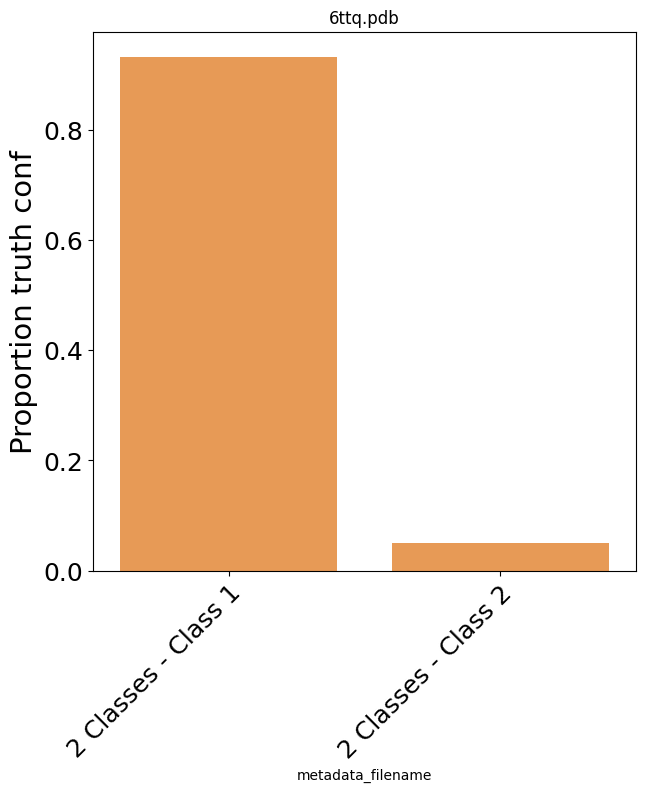

In [58]:
import itertools
palette = itertools.cycle(sns.color_palette())

"""
for each_class in order:
    sns.barplot(
        x=order,
        # y="/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb",# order,
        data=proportion_class_df,
        ax=ax,
        # fliersize=0,
        color=next(palette),
        hue="metadata_filename"
    )
"""
for i, pdb in enumerate(closest_pdb_filename):
    plt.clf()
    fig, ax = plt.subplots(figsize=(7, 3.5))

    sns.barplot(
        data=proportion_class_df,
        x="metadata_filename", # 
        y=pdb, # 
        # hue="metadata_filename", # this is the class
        color=next(palette),
        alpha=0.8,
    )


    ax.set_xticklabels(
        [jobtypes[metadata_filename] for metadata_filename in order],
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=12,
    )
    ax.set_yticklabels(
        [0.,0.2,0.4,0.6,0.8,1.0,1.2],
        fontsize=12,
    )
    # remove legend
    ax.legend().remove()

    ax.set_title(os.path.basename(pdb))
    fig.set_size_inches(7, 7)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=18)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=18)
    ax.set_ylabel("Proportion truth conf", fontsize=21)

    fig.savefig(os.path.join(figures_dir, "{}_classes_prop.pdf".format(i)), bbox_inches="tight")
    fig.savefig(os.path.join(figures_dir, "{}_class_prop.png".format(i)), bbox_inches="tight", dpi=600)

### Now making bar plots of 10 classes case

In [59]:
project_dir = "/mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included"
config_dir = os.path.join(project_dir, "Micrographs")
figures_dir = os.path.join(project_dir, "figures-3DClassDists10Classes")

meta_files = [
    os.path.join(project_dir, "Select", "job080", "particles.star"),
    os.path.join(project_dir, "Select", "job081", "particles.star"),
    os.path.join(project_dir, "Select", "job082", "particles.star"),
    os.path.join(project_dir, "Select", "job083", "particles.star"),
    os.path.join(project_dir, "Select", "job084", "particles.star"),
]

jobtypes = {
    os.path.join(project_dir, "Select", "job080", "particles.star"): "10 Classes - Class 3",
    os.path.join(project_dir, "Select", "job081", "particles.star"): "10 Classes - Class 5",
    os.path.join(project_dir, "Select", "job082", "particles.star"): "10 Classes - Class 6",
    os.path.join(project_dir, "Select", "job083", "particles.star"): "10 Classes - Class 2",
    os.path.join(project_dir, "Select", "job084", "particles.star"): "10 Classes - Class 10",
}

particle_diameter = 100 # approximate particle diameter in Angstroms
ugraph_shape = (4000, 4000) # shape of the micrograph in pixels. Only needs to be given if the metadata file is a .star file
verbose = True # prints out progress statements
ignore_missing_files = True # if .mrc files are missing, the analysis will still be performed
enable_tqdm = True # enables tqdm progress bars

for i, meta_file in enumerate(meta_files):
    if i == 0:
        analysis = load_data(meta_file, config_dir, particle_diameter, ugraph_shape=ugraph_shape, verbose=verbose, enable_tqdm=enable_tqdm, ignore_missing_files=ignore_missing_files) # creates the class
    else:
        analysis.add_data(meta_file, config_dir, verbose=verbose) # updates the class with the next metadata file
    
df_picked = pd.DataFrame(analysis.results_picking)
df_truth = pd.DataFrame(analysis.results_truth)
df_precision, df_picked, closest_pdb_filename = analysis.compute_precision(df_picked, df_truth, verbose=verbose)

print(closest_pdb_filename)

loading metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job080/particles.star...
loaded metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job080/particles.star. determined file type: star


Dictionaries now contain 2737 reconstructed particles
added 2737 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job080/particles.star


loading truth data: 100%|██████████| 55/55 [00:10<00:00,  5.03it/s, micrograph=000054.mrc]


Loaded ground-truth particle positions from config files
Dictionaries now contain 2737 particles and 16500 true particles
Added 16500 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Micrographs
loading metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job081/particles.star...
loaded metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job081/particles.star. determined file type: star
checking if ugraphs exist...


Dictionaries now contain 5830 reconstructed particles
added 3093 particles from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job081/particles.star
loading metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job082/particles.star...
loaded metadata from /mnt/dinaMISMO/synthetic_datasets/MapReconstruction/PKM2/NoMD_BDomain_Included/Select/job082/part

computing precision: 100%|██████████| 275/275 [00:04<00:00, 60.02it/s, precision=1, recall=0.0709, multiplicity=0.0833]    


time taken to compute precision: 4.6025848388671875
['/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb', '/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttq.pdb']


In [60]:
# make df to hold proportion of each class which comes from each truth_conformation
proportion_class = {
    "metadata_filename": [],
}

for i,truth_conf in enumerate(closest_pdb_filename):
    proportion_class[truth_conf] = []

# loop through each class. There's 1 per metadata file, so loop through metadata files
order = []
for r in meta_files:
    if type(r) == str:
        order.append(r)
    else:
        order.append(r[0])

for metadata_filename in order:
    proportion_class["metadata_filename"].append(metadata_filename)

    # because we have df_picked composed of multiple metadata files, we select just this one to
    # use to calc to proportions of truth conformation in each class
    df_picked_metadata_file = df_picked[df_picked["metadata_filename"]==metadata_filename]
    for i, truth_conf in enumerate(closest_pdb_filename):
        # for this truth conf get proportion which are from this class
        # print(df_picked["closest_pdb"].tail())
        # print(truth_conf)
        proportion_class[truth_conf].append(
            len(df_picked_metadata_file[
                df_picked_metadata_file["closest_pdb"].str.contains(truth_conf)
            ])/len(
                df_picked_metadata_file
            )
        )
        

In [62]:
proportion_class_df = pd.DataFrame.from_dict(proportion_class)
proportion_class_df.tail()

,metadata_filename,/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb,/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttq.pdb
0,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.020095,0.979905
1,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.976075,0.023925
2,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.051495,0.948505
3,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.924320,0.075680
4,/mnt/dinaMISMO/synthetic_datasets/MapReconstru...,0.512941,0.487059


/tmp/ipykernel_2338603/4018693408.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_2338603/4018693408.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(
/tmp/ipykernel_2338603/4018693408.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_2338603/4018693408.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=18)
/tmp/ipykernel_2338603/4018693408.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

<Figure size 640x480 with 0 Axes>

<Figure size 700x700 with 0 Axes>

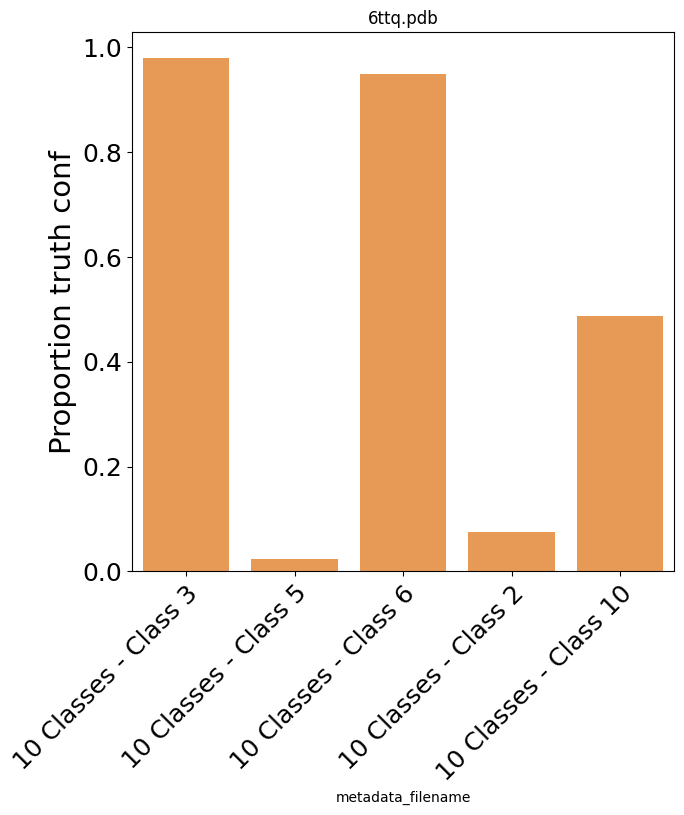

In [63]:
import itertools
palette = itertools.cycle(sns.color_palette())

"""
for each_class in order:
    sns.barplot(
        x=order,
        # y="/mnt/dinaMISMO/synthetic_datasets/ConformationSampling/PKM2/NoMD_BDomain_Included/6ttf.pdb",# order,
        data=proportion_class_df,
        ax=ax,
        # fliersize=0,
        color=next(palette),
        hue="metadata_filename"
    )
"""
for i, pdb in enumerate(closest_pdb_filename):
    plt.clf()
    fig, ax = plt.subplots(figsize=(7, 3.5))

    sns.barplot(
        data=proportion_class_df,
        x="metadata_filename", # 
        y=pdb, # 
        # hue="metadata_filename", # this is the class
        color=next(palette),
        alpha=0.8,
    )


    ax.set_xticklabels(
        [jobtypes[metadata_filename] for metadata_filename in order],
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=12,
    )
    ax.set_yticklabels(
        [0.,0.2,0.4,0.6,0.8,1.0,1.2],
        fontsize=12,
    )
    # remove legend
    ax.legend().remove()

    ax.set_title(os.path.basename(pdb))
    fig.set_size_inches(7, 7)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=18)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=18)
    ax.set_ylabel("Proportion truth conf", fontsize=21)

    fig.savefig(os.path.join(figures_dir, "{}_classes_prop.pdf".format(i)), bbox_inches="tight")
    fig.savefig(os.path.join(figures_dir, "{}_class_prop.png".format(i)), bbox_inches="tight", dpi=600)